Q1: Top 5 Locations by Outlet Count:
location
BTM                      3906
Koramangala 5th Block    2297
HSR                      2004
Indiranagar              1803
JP Nagar                 1717
Name: count, dtype: int64

Q2: Top 5 Cuisines:
cuisines
North Indian    17310
Chinese         12930
South Indian     6369
Fast Food        6340
Continental      5202
Name: count, dtype: int64

Q3: Average Customer Rating:
3.7

Q4: Top 5 Locations by Average Rating:
location
Lavelle Road             4.141788
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.006661
Church Street            3.992125
Name: rate, dtype: float64

Q5: Online Order Availability Percentage:
online_order
Yes    65.679787
No     34.320213
Name: proportion, dtype: float64


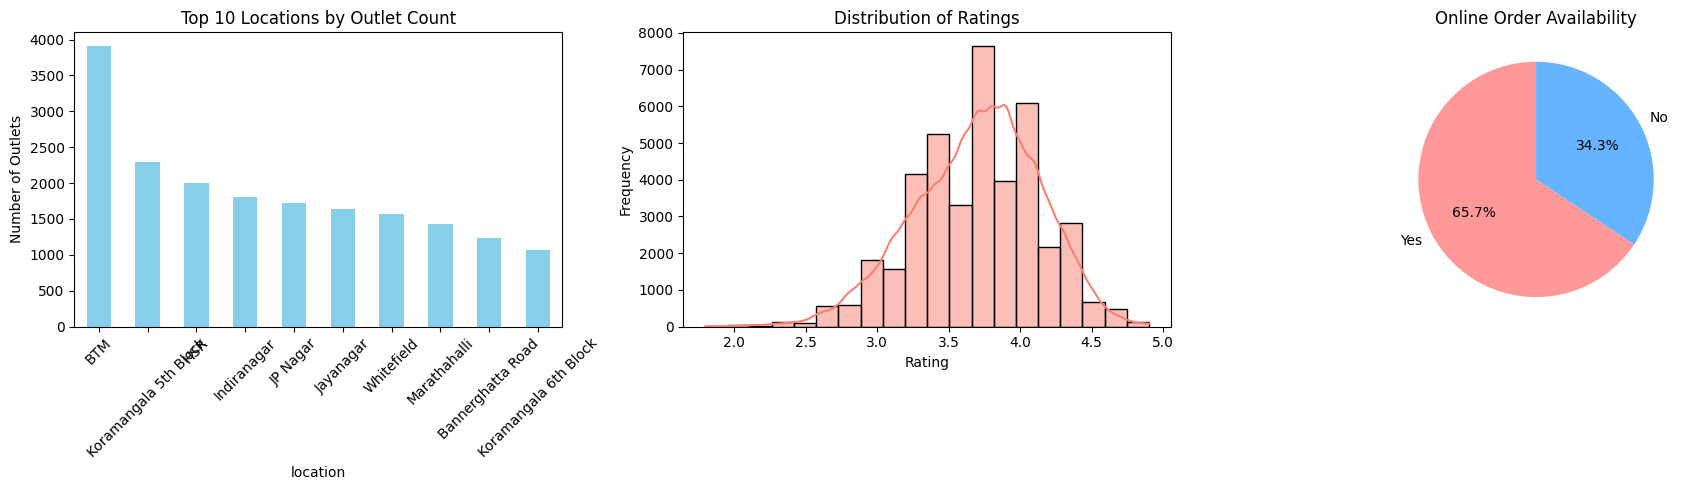

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/charan2008m/zomato-dataset/zomato.csv')

df = df.dropna(subset=['rate', 'location', 'cuisines', 'online_order', 'approx_cost(for two people)'])
df = df.drop_duplicates()

def clean_rate(rate):
    if isinstance(rate, str) and '/' in rate:
        return float(rate.split('/')[0])
    return None

df['rate'] = df['rate'].apply(clean_rate)
df = df.dropna(subset=['rate'])

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

print("Q1: Top 5 Locations by Outlet Count:")
print(df['location'].value_counts().head())

print("\nQ2: Top 5 Cuisines:")
all_cuisines = df['cuisines'].str.split(', ').explode()
print(all_cuisines.value_counts().head())

print("\nQ3: Average Customer Rating:")
print(round(df['rate'].mean(), 2))

print("\nQ4: Top 5 Locations by Average Rating:")
print(df.groupby('location')['rate'].mean().sort_values(ascending=False).head())

print("\nQ5: Online Order Availability Percentage:")
print(df['online_order'].value_counts(normalize=True) * 100)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
df['location'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Locations by Outlet Count')
plt.ylabel('Number of Outlets')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.histplot(df['rate'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Online Order Availability')
plt.ylabel('')

plt.tight_layout()
plt.show()